<a href="https://colab.research.google.com/github/anamasotedta/ConnectaTel-Analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.


El da
taset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

---

**👥 1. Dataset: `users`**

**`churn_date` (88.35% de nulos)**
* **Qué se observa:** La gran mayoría de los usuarios no tiene fecha de baja registrada.
* **Acción recomendada:** **Ignorar (Mantener los nulos)** y posiblemente crear una variable bandera/booleana `is_active`.
* **Justificación:** Aunque supera el umbral del 80%, en este contexto de negocio el nulo representa una excelente noticia: son los clientes que siguen activos en la empresa.

**`city` (11.73% de nulos)**
* **Qué se observa:** Una proporción moderada de usuarios no tiene asociada su ciudad de origen.
* **Acción recomendada:** **Imputar** con el valor categórico `'Desconocida'`.
* **Justificación:** Cae en el rango del 5% al 30%, lo que permite conservar el resto de la información del usuario (edad, plan, etc.) sin sesgar las estadísticas de las ciudades reales.

---

**📈 2. Dataset: `usage`**

**`duration` (55.19% de nulos) y `length` (44.74% de nulos)**
* **Qué se observa:** Pérdida de datos estructural (*Missing by Design*). Las proporciones se complementan casi a la perfección según el tipo de servicio (`type`).
* **Acción recomendada:** **Imputar con `0`** (previo chequeo con un `groupby` por tipo de servicio).
* **Justificación:** No son errores del sistema: las llamadas no generan longitud de datos (MB) y los datos/SMS no generan duración en minutos.

**`date` (0.13% de nulos)**
* **Qué se observa:** Una cantidad mínima de registros de consumo (50 filas de 40,000) no guardó la fecha del evento.
* **Acción recomendada:** **Eliminar** las 50 filas afectadas usando `.dropna(subset=['date'])`.
* **Justificación:** Al ser una proporción significativamente menor al 5%, su eliminación limpia el histórico temporal sin afectar el volumen del dataset.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
display(users.describe())

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene 4,000 registros con identificadores numéricos distribuidos uniformemente del 10000 al 13999, por lo que sus métricas estadísticas no tienen relevancia práctica para el análisis.
- La columna `age` revela un valor mínimo erróneo de -999.000000 que actúa como un código de error y sesga el promedio, aunque la población real se concentra mayormente entre los 32 y 79 años.

In [ ]:
# explorar columnas numéricas de usage
display(usage.describe())

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` funcionan como identificadores secuenciales (40,000 registros en total) y de usuarios (en el rango de 10,000 a 13,999), por lo que sus métricas estadísticas no aportan valor analítico práctico.
- La columna `duration` registra 17,924 llamadas con una duración promedio de 5.2 minutos, mostrando un comportamiento estándar que llega hasta un máximo de 120 minutos, además de llamadas con duración 0 (probablemente perdidas o no contestadas).
- La columna `length` registra 22,104 eventos de consumo de datos con una media de 52.1, pero evidencia un sesgo importante hacia la derecha debido a un valor máximo atípico (outlier) extremadamente alto de 1,490, que duplica ampliamente al tercer cuartil (64).

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
display(users[columnas_user].describe(include='O'))

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` registra un total de 3,531 registros no nulos, distribuidos en 7 ciudades distintas, de las cuales Bogotá es la más frecuente con 808 apariciones.
- La columna `plan` cuenta con sus 4,000 registros completos distribuidos en solo 2 planes comerciales únicos, donde el plan Basico es el dominante con una presencia masiva de 2,595 usuarios.

In [ ]:
# explorar columna categórica de usage
columnas_usage = ['type']
display(usage[columnas_usage].describe(include='O'))

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` cuenta con los 40,000 registros completos del dataset distribuidos en 2 tipos de servicios únicos, donde el servicio de text (SMS/datos) es el más frecuente con 22,092 eventos registrados.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  

- La columna `age` (en `users`): Aparece una edad mínima de -999. Esto no es una edad real; es un "valor centinela.
**Acción**: Se podría borrar ese -999 y cambiarlo por la mediana de edad de todos los usuarios.
- La columna `length` (en `usage`): Hay un consumo máximo de 1,490 MB, mientras que la gran mayoría de los usuarios gasta alrededor de 52 o máximo 64 MB. Es un consumo exageradamente alto (un outlier) que nos va a alterar los promedios.
**Acción**: Se aplicaria clipping (capar el valor), lo que significa ajustar ese pico exagerado al límite del percentil 99

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Revisamos cuántas veces aparece cada año (incluyendo nulos si los hay)
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


In [ ]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Revisamos cuántas veces aparece cada año (incluyendo nulos si los hay)
print(usage['date'].dt.year.value_counts(dropna=False).sort_index())

2024.0    39950
NaN          50
Name: date, dtype: int64


In [ ]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.unique())

[2022 2026 2023 2024]


En `reg_date`, se encuentran datos de 2026, teniendo en cuenta que se debería tener información únicamente hasta el año 2024, esto es un error.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.unique())

[2024.   nan]


En `date`, se encuentran únicamente datos del año 2024. Por esta razón basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
Aparece el año 2026 como imposible porque rompe la regla de negocio que limita los datos de ConnectaTel hasta el año 2024; para solucionarlo, lo ideal es convertir esas fechas futuras en valores nulos (NaT), ya que al no tener certeza de si corresponden originalmente a 2022, 2023 o 2024, transformarlas en nulos evita que contaminen la línea de tiempo del proyecto y nos permite manejarlas limpiamente en el bloque de limpieza general.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration


In [ ]:
# Verificación MAR en usage (Missing At Random) para length


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")

# observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
display(user_profile.drop(columns=['user_id'], errors='ignore').describe())

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
display(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

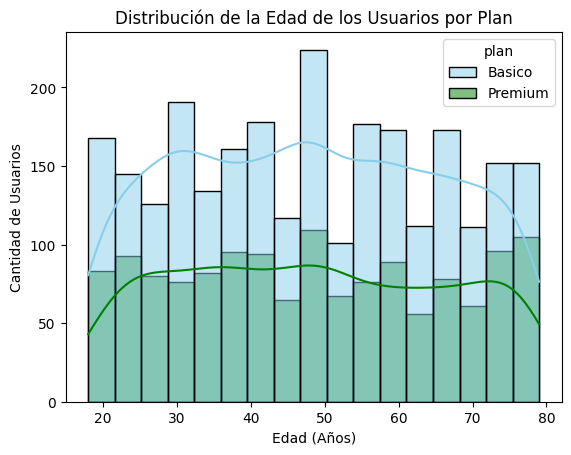

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la Edad de los Usuarios por Plan')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights:
- Análisis por plan: No existe algún patrón claro que diferencie los planes por edad; la distribución de los usuarios del plan Básico y Premium es prácticamente idéntica a lo largo de toda la gráfica. Tanto los jóvenes de 20 años como los adultos de casi 80 eligen ambos planes por igual.

- Tipo de distribución: Tiene una distribución uniforme (plana). No vemos una campana normal ni sesgos acumulados a los lados; la cantidad de clientes se mantiene muy estable y bien repartida entre los 18 y los 79 años, exceptuando un pequeño pico de usuarios del plan Básico rondando los 48-50 años.

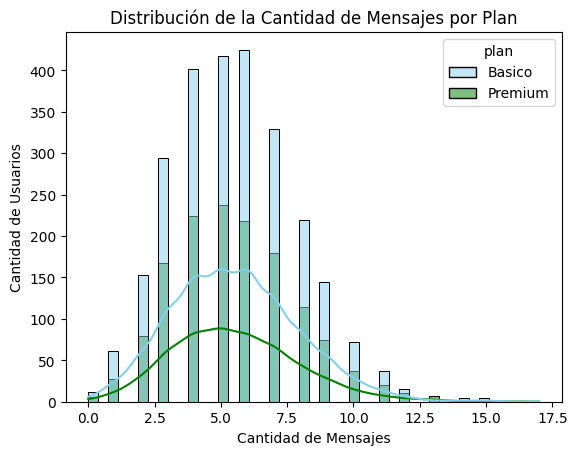

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- Análisis por plan: Los usuarios de ambos planes tienen un comportamiento de uso idéntico. No hay una diferencia real entre el plan Básico y el Premium; ambos grupos concentran su mayor volumen de personas enviando la misma cantidad de textos. La única diferencia visual en las barras es que hay más usuarios registrados en el plan Básico en general.

- Tipo de distribución: Tiene una distribución sesgada a la derecha (sesgo positivo). El uso se estabiliza y tiene su punto más fuerte entre los 4 y 6 mensajes por usuario, y a partir de ahí empieza a caer drásticamente. Muy pocos usuarios llegan a enviar más de 10 mensajes.

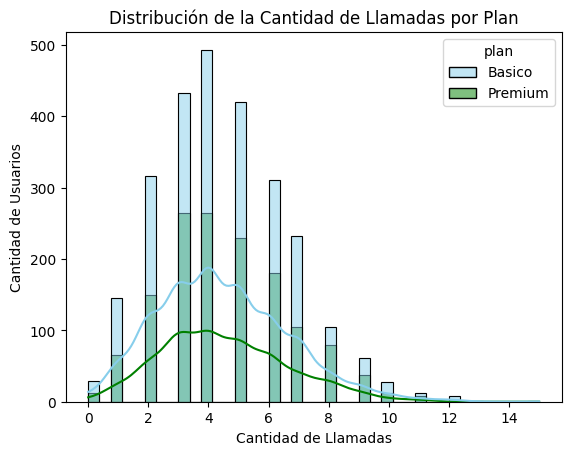

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- Análisis por plan: Se repite la misma tendencia que con los mensajes: no existe un patrón de comportamiento diferente según el plan elegido. Los usuarios del plan Básico y Premium tienden a realizar exactamente la misma cantidad de llamadas, concentrándose de igual manera en el centro de la gráfica.

- Tipo de distribución: Tiene una distribución sesgada a la derecha. El pico más alto de usuarios se concentra fuertemente entre las 3 y 5 llamadas por cliente, y a partir de las 6 llamadas la cantidad de usuarios empieza a bajar de forma constante. Es extremadamente raro ver a un cliente que supere las 10 llamadas.

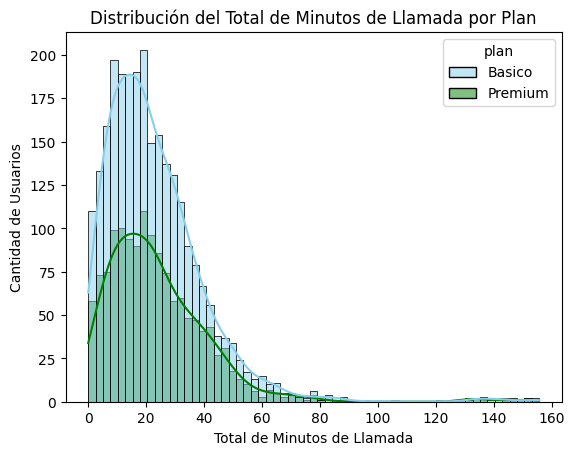

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución del Total de Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡Insights:
- Análisis por plan: Manteniendo la misma tendencia que en las métricas anteriores, no existe una diferencia en el patrón de consumo entre los usuarios del plan Básico y Premium. Ambos perfiles hablan por teléfono casi la misma cantidad de tiempo, reflejando que la elección del plan no está amarrada a la necesidad de pasar más minutos en una llamada.

- Tipo de distribución: Tiene una distribución fuertemente sesgada a la derecha. La gran mayoría de los clientes acumula entre 10 y 25 minutos de conversación en total. Después de los 40 minutos la curva cae abruptamente, aunque se observa una cola muy larga con unos poquísimos usuarios extremos que llegan a rozar los 160 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

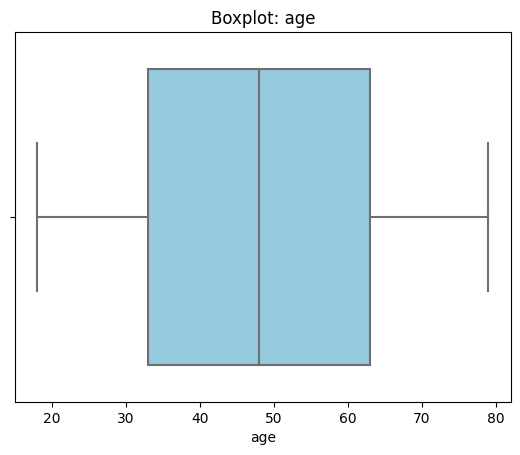

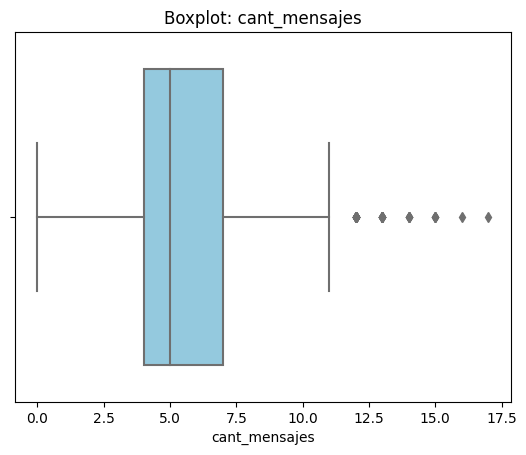

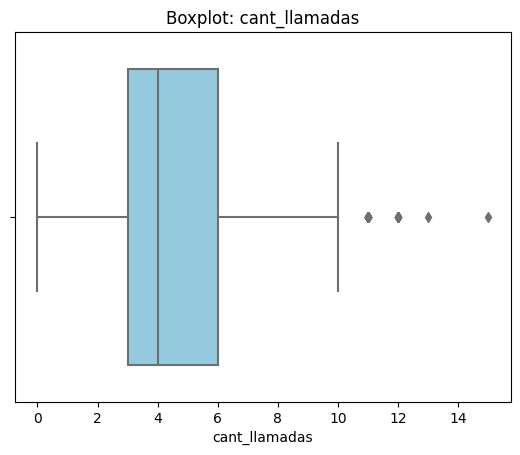

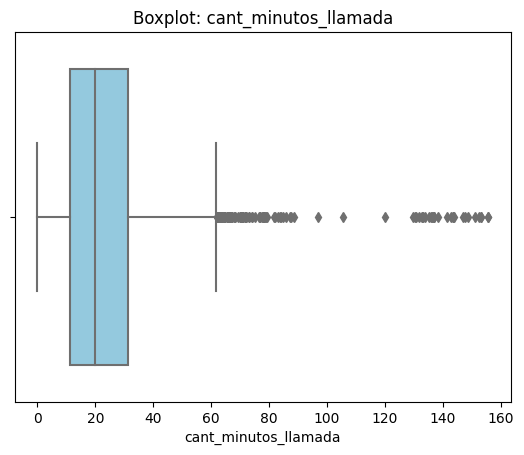

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    if col in user_profile.columns:
        sns.boxplot(data=user_profile, x=col, hue='plan', palette=['skyblue', 'green'])
        plt.title(f'Boxplot: {col}')
        plt.show()

💡Insights:
- Age: No presenta outliers. La caja abarca perfectamente el rango de edad de los usuarios sin que ningún punto se escape de los bigotes.
- cant_mensajes: Sí presenta outliers en el extremo derecho (valores superiores a 11 mensajes).
- cant_llamadas: Sí presenta outliers en el extremo derecho (valores superiores a 10 llamadas).
- cant_minutos_llamada: Sí presenta una cantidad importante de outliers en el extremo derecho (valores superiores a los 62 minutos aproximadamente, extendiéndose con una cola muy larga hasta casi los 160 minutos).

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    if col in user_profile.columns:
        # Calcular Q1, Q3 e IQR
        q1 = user_profile[col].quantile(0.25)
        q3 = user_profile[col].quantile(0.75)
        iqr = q3 - q1

        # Calcular el límite superior
        limite_superior = q3 + 1.5 * iqr

        # Aplicar el ajuste (Capping) para reemplazar los outliers
        user_profile[col] = user_profile[col].clip(upper=limite_superior)

        print(f"Límite superior para {col}: {limite_superior:.2f} -> ¡Valores ajustados!")

Límite superior para cant_mensajes: 11.50 -> ¡Valores ajustados!
Límite superior para cant_llamadas: 10.50 -> ¡Valores ajustados!
Límite superior para cant_minutos_llamada: 61.86 -> ¡Valores ajustados!


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.508377,4.470868,22.532895
std,2.308822,2.120840,14.790722
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,11.500000,10.500000,61.857500


💡Insights:

- cant_mensajes: (Mantener el ajuste): Los números en esta variable son sumamente bajos de por sí (el 75% de los usuarios envía 7 mensajes o menos). Un usuario con 15 o 17 mensajes, aunque parece poco en el mundo real, estadísticamente distorsiona la media de una base de datos tan pequeña. El ajuste a 11.5 funciona para estabilizar los datos.

- cant_llamadas: (Mantener el ajuste): Al igual que los mensajes, el comportamiento es muy estricto; la gran mayoría hace entre 3 y 6 llamadas. Las personas con más de 11 llamadas rompen el esquema típico del usuario común. Dejar el tope en 10.5 limpia el ruido.

- cant_minutos_llamada: (Mantener el ajuste): Esta es la variable más crítica. El 75% de las personas habla máximo 31 minutos, pero hay usuarios con 160 minutos. Dejar esos valores originales jalaría la media artificialmente hacia arriba, haciendo creer al negocio que los usuarios consumen más tiempo de lo que el cliente promedio realmente hace. Limitarlo a 61.85 minutos es la mejor decisión

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def categorizar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(categorizar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.



**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos



In [ ]:
# Crear columna grupo_edad
def categorizar_edad(fila):
    if fila['age'] < 30:
        return 'Joven'
    elif fila['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(categorizar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

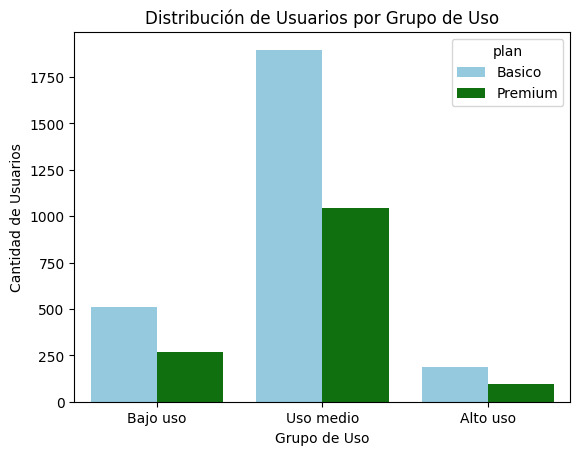

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    hue='plan',
    palette=['skyblue', 'green'],
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

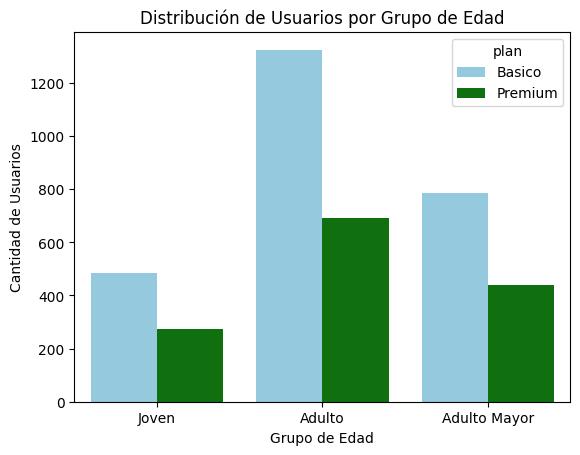

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    hue='plan',
    palette=['skyblue', 'green'],
    order=['Joven', 'Adulto', 'Adulto Mayor']
)
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores nulos ocultos con caracteres extraños: La columna `city` tenía signos de interrogación (?) en lugar de datos limpios, ocultando la falta de información en varios registros.

- Fechas inconsistentes y futuras: En `reg_date` se detectaron registros con años que superaban el 2024, lo cual lógicamente es un error de captura o corrupción de datos que se marcaron como NaT.

- Presencia extrema de outliers por el extremo derecho: Las columnas de consumo (`cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada`) tenían colas larguísimas y picos desproporcionados. El caso más crítico fue el de los minutos de llamada, donde el 75% de la gente hablaba máximo 31 minutos, pero se encontraron registros atípicos de hasta 160 minutos que representaban aproximadamente un 5% de usuarios con consumos sumamente inflados.

🔍 **Segmentos por Edad**
- Predominio del segmento Adulto: El grupo más grande de ConnectaTel está compuesto por los 'Adultos' (30 a 59 años), seguidos por los 'Adultos Mayores' (60 años o más), dejando a los 'Jóvenes' (menores de 30) como el grupo más pequeño.

- Comportamiento idéntico entre planes: No importa la edad del usuario; tanto los usuarios jóvenes de 20 años como los usuarios de 75 eligen el plan Básico y el Premium exactamente en la misma proporción. La edad no discrimina qué plan van a comprar.


📊 **Segmentos por Nivel de Uso**
- Concentración masiva en 'Uso medio': La gran mayoría de los clientes cayó en la categoría de 'Uso medio' (entre 5 y 10 llamadas/mensajes), mientras que una porción muy pequeña se quedó en 'Alto uso' o 'Bajo uso'.

- Falta de correspondencia con el plan contratado: Los usuarios de 'Alto uso' no están migrando al plan Premium, y los de 'Bajo uso' tampoco se quedan solo en el Básico. El comportamiento de consumo actual de llamadas y mensajes está totalmente desconectado del plan que pagan.

➡️ Esto sugiere que los clientes actuales no están eligiendo su plan en función de cuántos minutos hablan o cuántos mensajes mandan en su día a día, ya que los histogramas y perfiles de consumo son una representación entre el plan Básico y el Premium. Esto nos indica que el plan Premium probablemente se esté vendiendo por otros beneficios que no estamos viendo aquí (como gigas de internet, beneficios de roaming o simples estrategias de marketing), o bien, que ConnectaTel tiene una fuga de valor enorme con usuarios de 'Alto uso' que se están aprovechando del plan Básico sin incentivos reales para mejorar su cuenta.


💡 **Recomendaciones**

- Reestructurar los límites de los planes (Frenar los Outliers): Basado en el límite superior que se encontro con el IQR (61.85 minutos), se recomienda poner un tope estricto de 60 minutos de llamada en el plan Básico. Si el cliente quiere hablar más de una hora, se le debe forzar a pagar un extra o a migrar al plan Premium.

- Crear un plan enfocado en el segmento 'Adulto' y 'Uso Medio': Como este es el nicho más grande, se puede diseñar un plan intermedio o ajustar el Básico para que cubra exactamente ese rango de 4-6 llamadas y mensajes diarios, que es donde se concentra el dinero real de la operación.

- Lanzar campañas de Up-selling dirigidas: Identificar explícitamente al grupo de 'Alto uso' que actualmente está registrado en el plan Básico, y enviarles promociones directas para mudarse a Premium, demostrándoles que por su ritmo de consumo les conviene una tarifa plana o mayores beneficios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`